In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.data_loader import get_validated_data
from src.data.process_data import calculate_stadistics
from src.data.process_data import freq_of_freqs
from src.data.process_data import group_and_sum
from src.visualization.prints import print_analysis_results
from src.visualization.plots import make_plot
from src.visualization.plots import multiple_lineplot
from src.data.data_writer import export_eda_params

In [3]:
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_colwidth", None)
sns.set_style("darkgrid")

In [4]:
# Load the validated data
data = get_validated_data()
data.head(5)

,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,3057270,Seafarer's Gambit,2024,2024-07-05,Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,3822840,Capitalist Misadventures,2025,2025-07-25,Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios
2,3216640,The Beast and the Princess,2025,2025-06-17,Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controller support;Custom Volume Controls;Adjustable Difficulty;Playable without Timed Input;Steam Cloud;Steam Leaderboards;Family Sharing,12.99,0,Libragames,Libragames
3,2403620,Air Twister,2023,2023-11-10,Action;Adventure;Indie,Single-player;Steam Achievements;Full controller support;Steam Cloud;Family Sharing,24.99,0,YS Net,ININ
4,1538040,Horde Slayer,2021,2021-03-19,Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controller support;Steam Cloud;Family Sharing,3.99,0,Wagner Rodrigues,Wagner Rodrigues


## Univariate Analysis

In [5]:
# General information
print(
    f"\n---Description--- \n{data[['release_date', 'price', 'recommendations']].describe()}"
)


---Description--- 
                     release_date         price  recommendations
count                       63995  63995.000000     63995.000000
mean   2023-12-10 12:10:47.375576      7.362776       369.666818
min           2021-01-01 00:00:00      0.000000         0.000000
25%           2022-10-25 00:00:00      0.990000         0.000000
50%           2024-03-07 00:00:00      4.990000         0.000000
75%           2025-03-04 00:00:00      9.990000         0.000000
max           2025-12-31 00:00:00   1900.000000    862487.000000
std                           NaN     17.078056      7018.511212


In [6]:
# Release date analysis
release_years_count = data["release_year"].value_counts()
release_dates = data["release_date"].value_counts()
daily_release_stats = calculate_stadistics(release_dates)
popular_release_dates = release_dates[
    release_dates > daily_release_stats["mean"]
].count()
releases_per_month = data["release_date"].dt.month.value_counts()
releases_per_year_month = (
    data.groupby(["release_year", data["release_date"].dt.month])
    .size()
    .reset_index(name="count")
)

print_analysis_results(
    "Release Date Analysis",
    {
        "Days with releases": release_dates.count(),
        "Days with above-average releases": popular_release_dates,
    },
)
print_analysis_results("Daily Release Stats", daily_release_stats)

================== Release Date Analysis ==================
Days with releases: 1825
Days with above-average releases: 781

================== Daily Release Stats ==================
count: 1825
mean: 35.0
mode: 17
median: 31.0
max: 150
min: 1



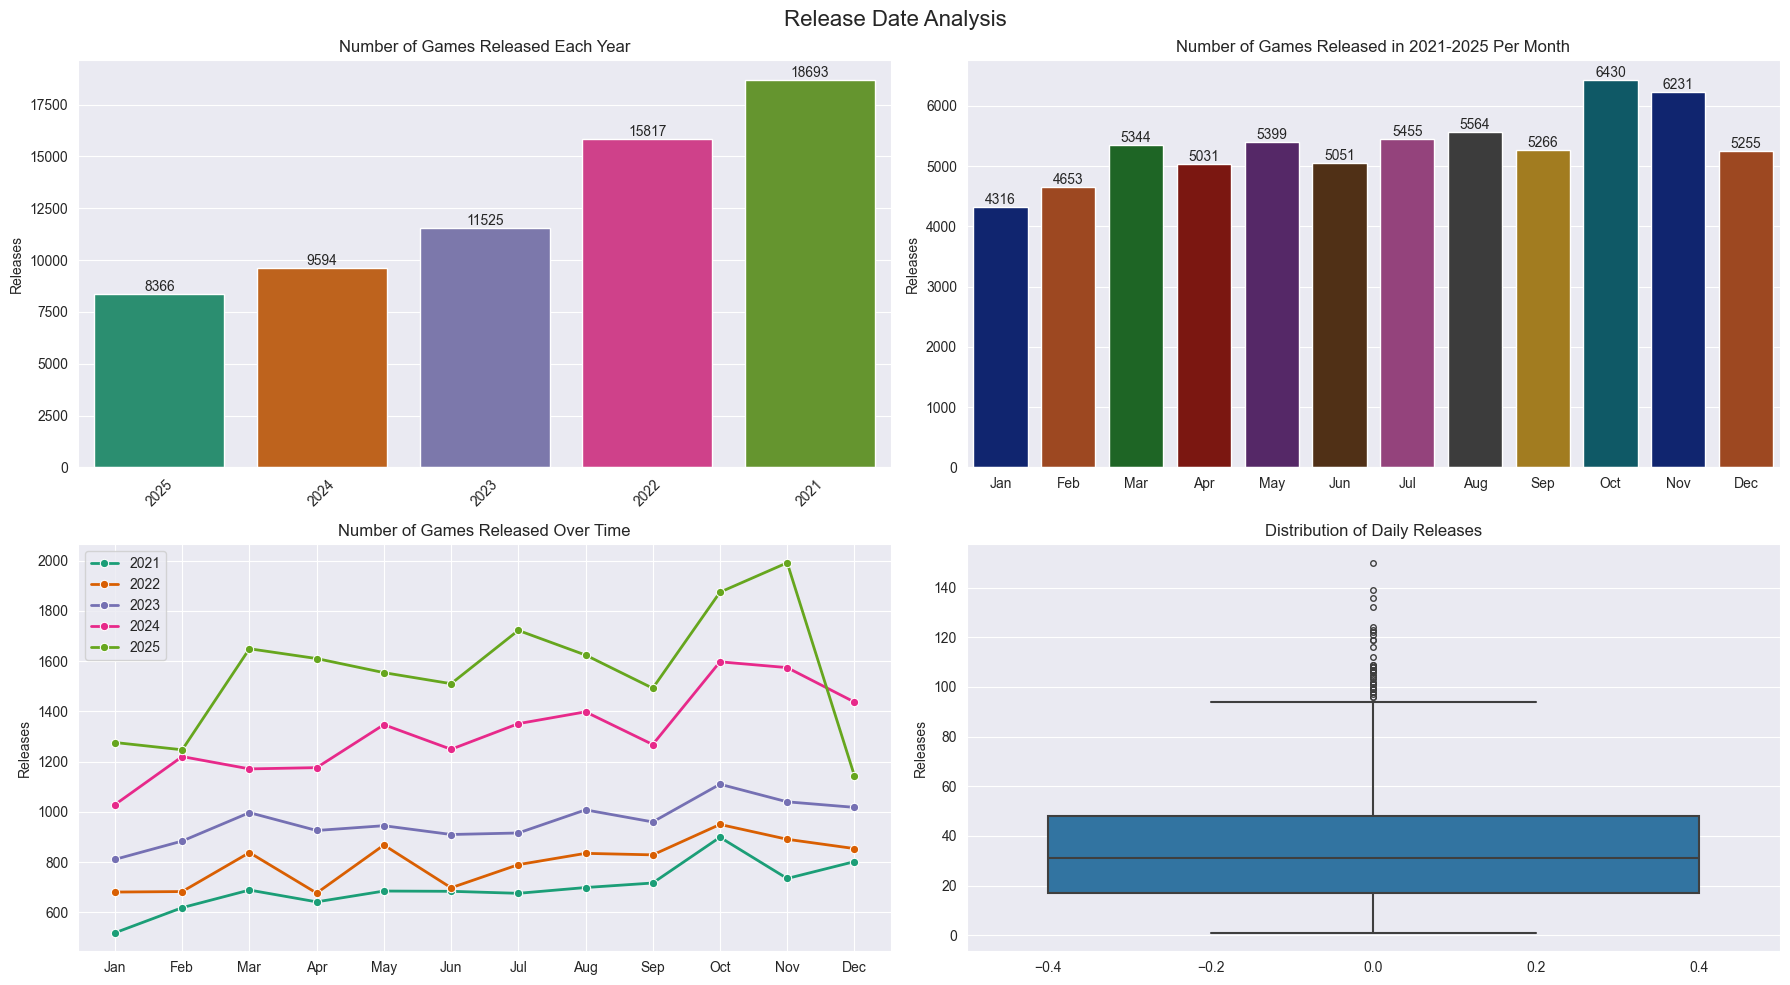

In [7]:
# Release date analysis plots

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Release Date Analysis", fontsize=16)
months_ticklabels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

make_plot(
    plot_type="bar",
    x_col=release_years_count.index,
    y_col=release_years_count.values,
    axes=axes[0, 0],
    title="Number of Games Released Each Year",
    ylabel="Releases",
    xticklabels=release_years_count.index,
    palette="Dark2",
    hue=release_years_count.index,
    rotation=45,
)

make_plot(
    plot_type="bar",
    x_col=releases_per_month.index,
    y_col=releases_per_month.values,
    axes=axes[0, 1],
    title="Number of Games Released in 2021-2025 Per Month",
    ylabel="Releases",
    palette="dark",
    hue=releases_per_month.index,
    xticklabels=months_ticklabels,
)

make_plot(
    data=releases_per_year_month,
    plot_type="line",
    x_col="release_date",
    y_col="count",
    axes=axes[1, 0],
    title="Number of Games Released Over Time",
    ylabel="Releases",
    palette="Dark2",
    xticklabels=months_ticklabels,
    hue="release_year",
    xticks=range(1, 13),
    legend=True,
    legend_label="Years",
)

make_plot(
    plot_type="box",
    x_col=None,
    y_col=release_dates.values,
    axes=axes[1, 1],
    title="Distribution of Daily Releases",
    palette="Dark2",
    ylabel="Releases",
)

plt.show()

In [8]:
# Genres analysis
splitted_genres = data["genres"].str.split(";")
genres_freq_of_freqs = freq_of_freqs(splitted_genres[splitted_genres.str.len() > 1])
most_popular_genres_combinations = genres_freq_of_freqs.head(10)
most_popular_genres_combinations["genres"] = most_popular_genres_combinations[
    "genres"
].str.join(";")
genres_count = splitted_genres.explode().value_counts()

genres_combinations_stats = calculate_stadistics(genres_freq_of_freqs["count"])
print_analysis_results("Genres Combinations Stats", genres_combinations_stats)

genres_stats = calculate_stadistics(genres_count)
print_analysis_results("Genres Analysis", genres_stats)

most_popular_genres = genres_count[genres_count.values > genres_stats["median"]]

================== Genres Combinations Stats ==================
count: 1693
mean: 33.0
mode: 1
median: 3.0
max: 4079
min: 1

================== Genres Analysis ==================
count: 22
mean: 8466.0
mode: 3
median: 1815.5
max: 45021
min: 1



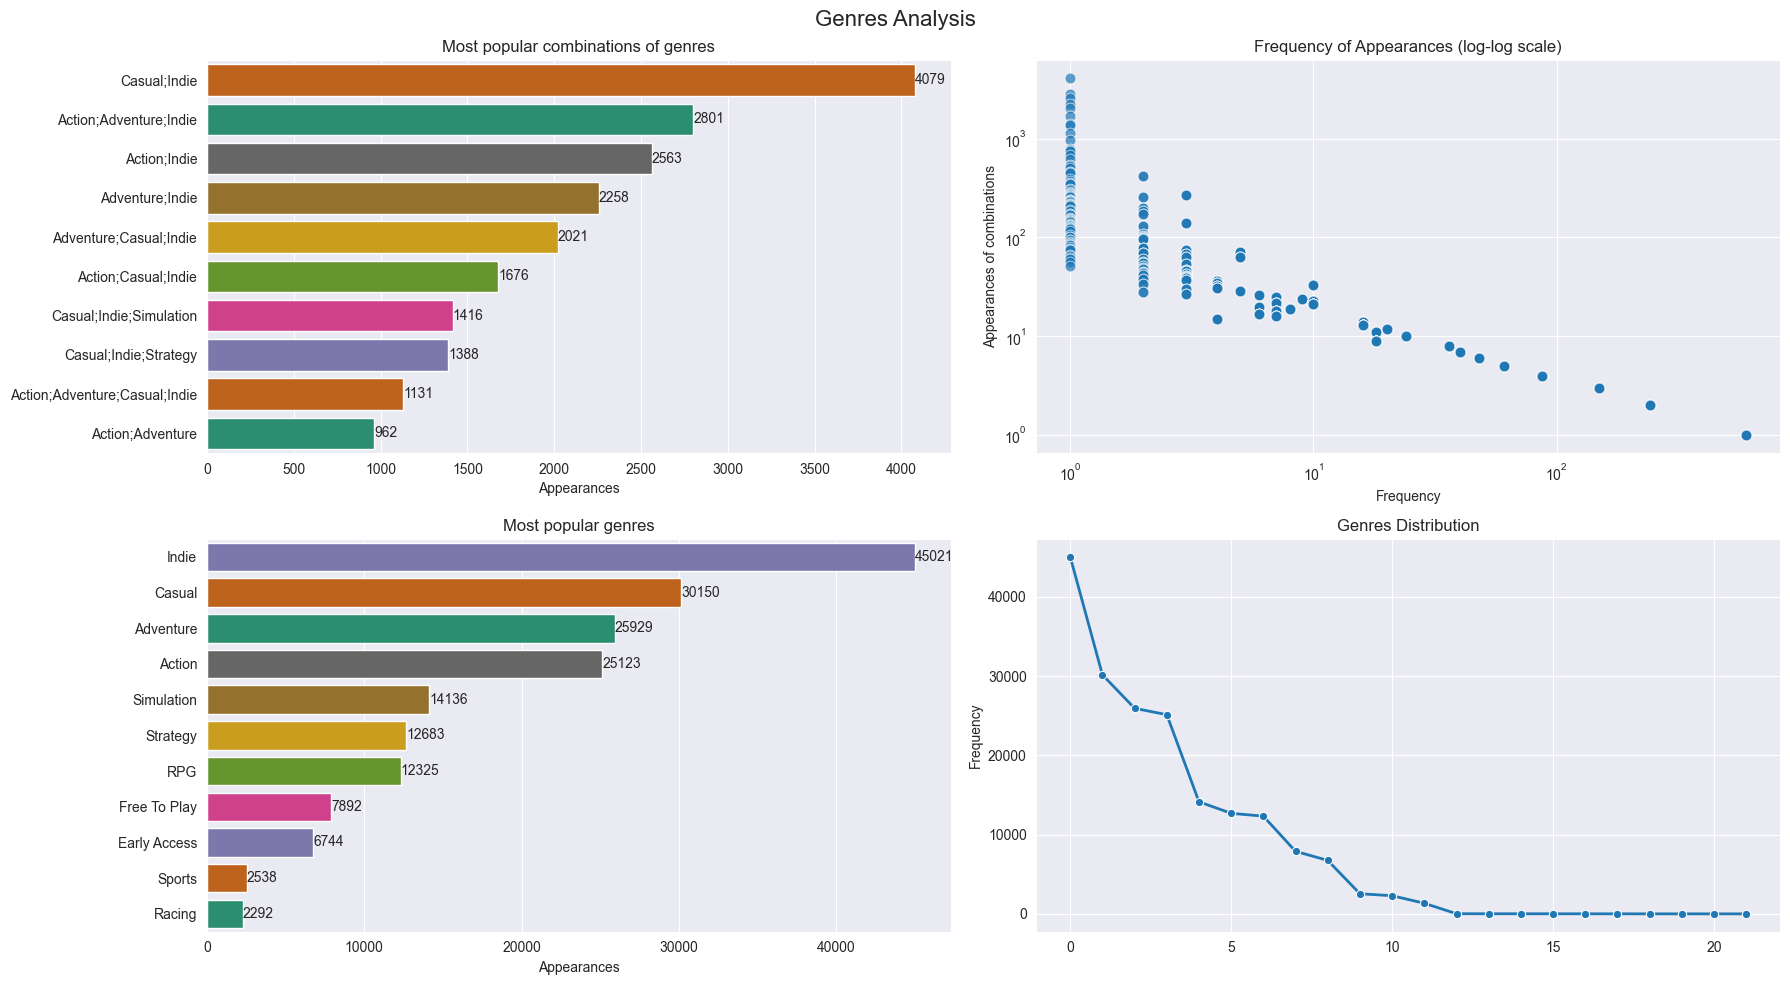

In [9]:
# Genres analysis plots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Genres Analysis", fontsize=16)

make_plot(
    plot_type="bar",
    data=most_popular_genres_combinations,
    x_col="count",
    y_col="genres",
    axes=axes[0, 0],
    title="Most popular combinations of genres",
    xlabel="Appearances",
    yticklabels=most_popular_genres_combinations["genres"],
    palette="Dark2",
    hue="count",
)

make_plot(
    plot_type="scatter",
    data=genres_freq_of_freqs,
    x_col="frequency",
    y_col="count",
    axes=axes[0, 1],
    title="Frequency of Appearances (log-log scale)",
    xlabel="Frequency",
    ylabel="Appearances of combinations",
    xscale="log",
    yscale="log",
)

make_plot(
    plot_type="bar",
    x_col=most_popular_genres.values,
    y_col=most_popular_genres.index,
    axes=axes[1, 0],
    title="Most popular genres",
    xlabel="Appearances",
    yticklabels=most_popular_genres.index,
    palette="Dark2",
    hue=most_popular_genres.values,
)

make_plot(
    data=genres_count.values,
    x_col=None,
    y_col=None,
    plot_type="line",
    axes=axes[1, 1],
    title="Genres Distribution",
    ylabel="Frequency",
)

plt.show()

genres
Indie           45021
Casual          30150
Adventure       25929
Action          25123
Simulation      14136
Strategy        12683
RPG             12325
Free To Play     7892
Early Access     6744
Sports           2538
Racing           2292
Name: count, dtype: int64


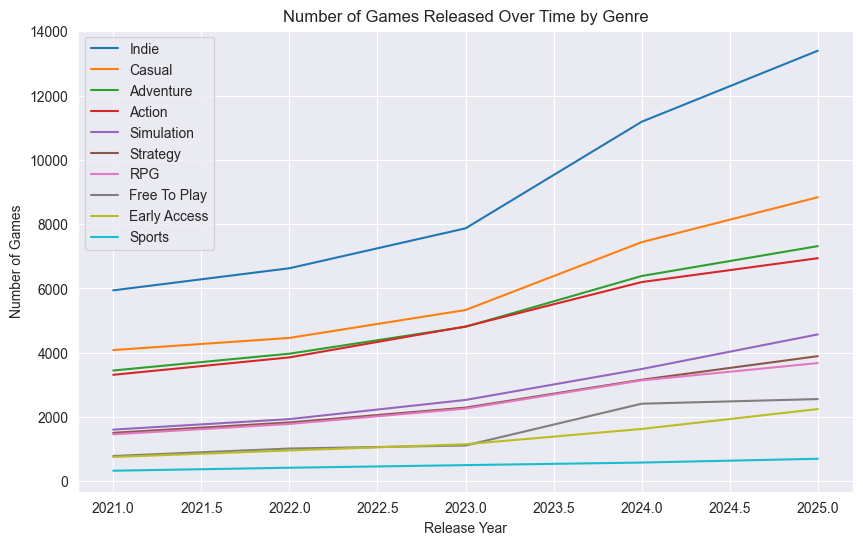

In [10]:
# Evolution of genres over time
plt.figure(figsize=(10, 6))
print(most_popular_genres)
genres_sum = group_and_sum(
    data=data,
    groups=most_popular_genres.index[:-1],
    group_by="release_year",
    sum_by="genres",
)
multiple_lineplot(
    genres_sum,
    title="Number of Games Released Over Time by Genre",
    xlabel="Release Year",
    ylabel="Number of Games",
)

In [11]:
# Categories analysis
splitted_categories = data["categories"].str.split(";")
categories_freq_of_freqs = freq_of_freqs(
    splitted_categories[splitted_categories.str.len() > 1]
)
most_popular_categories_combinations = categories_freq_of_freqs.head(10)

most_popular_categories_combinations["categories"] = (
    most_popular_categories_combinations["categories"].str.join(";")
)
most_popular_categories_combinations["categories"] = (
    most_popular_categories_combinations["categories"].apply(
        lambda x: "\n".join(x.split(";"))
    )
)
categories_count = splitted_categories.explode().value_counts()

popular_categories_combinations_stats = calculate_stadistics(
    categories_freq_of_freqs["count"]
)
print_analysis_results(
    "Categories Combination Analysis", popular_categories_combinations_stats
)
categories_count_stats = calculate_stadistics(categories_count)
print_analysis_results("Categories Analysis", categories_count_stats)

most_popular_categories = categories_count[
    categories_count.values > categories_count_stats["mean"]
]

================== Categories Combination Analysis ==================
count: 7692
mean: 8.0
mode: 1
median: 1.0
max: 14727
min: 1

================== Categories Analysis ==================
count: 54
mean: 5068.0
mode: 26
median: 1716.0
max: 61484
min: 7



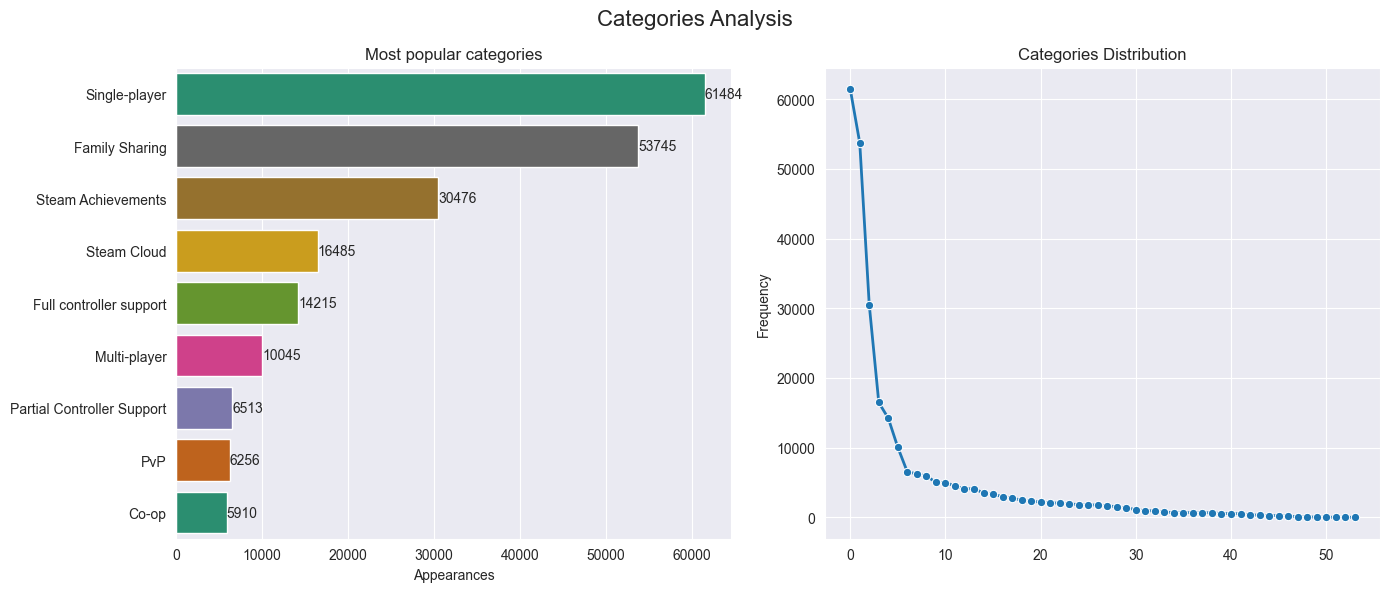

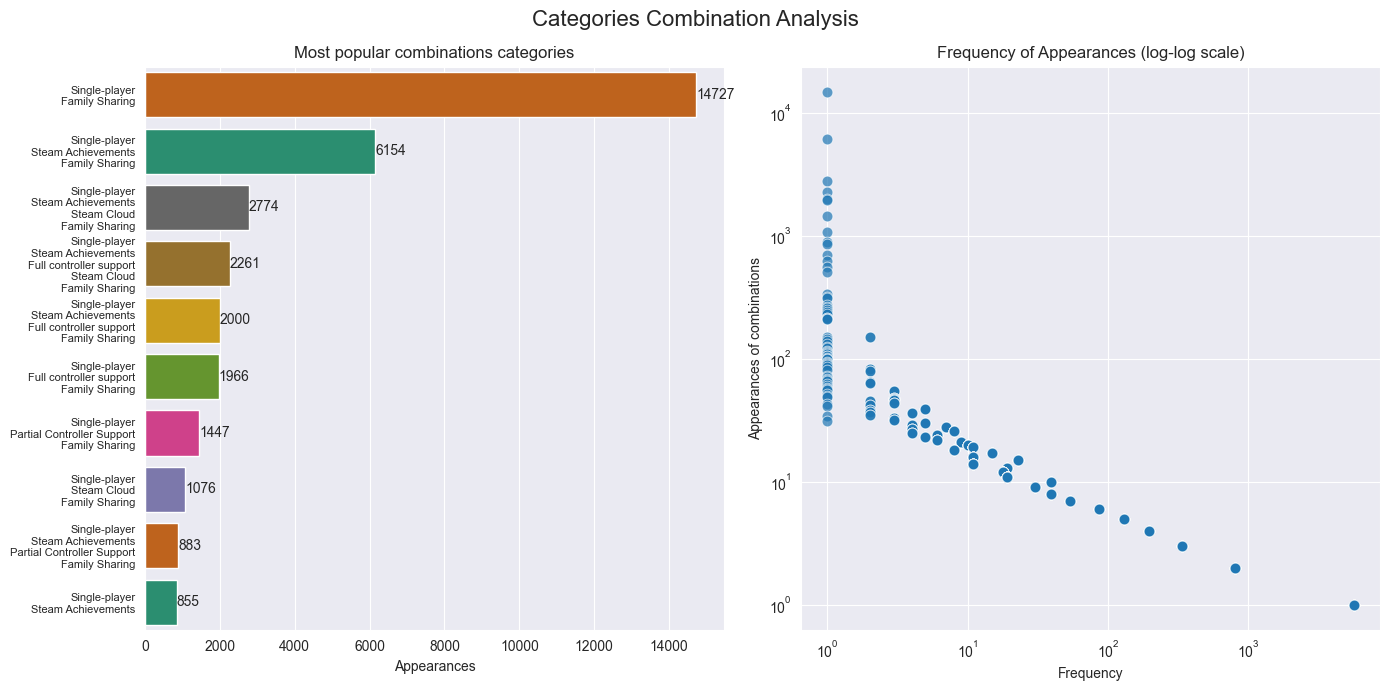

In [12]:
# Categories analysis plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Categories Analysis", fontsize=16)

make_plot(
    plot_type="bar",
    x_col=most_popular_categories.values,
    y_col=most_popular_categories.index,
    axes=axes[0],
    title="Most popular categories",
    xlabel="Appearances",
    yticklabels=most_popular_categories.index,
    palette="Dark2",
    hue=most_popular_categories.values,
)

make_plot(
    plot_type="line",
    data=categories_count.values,
    x_col=None,
    y_col=None,
    axes=axes[1],
    title="Categories Distribution",
    ylabel="Frequency",
)

# Categories combination analysis plots
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("Categories Combination Analysis", fontsize=16)

make_plot(
    plot_type="bar",
    data=most_popular_categories_combinations,
    x_col="count",
    y_col="categories",
    axes=axes[0],
    title="Most popular combinations categories",
    xlabel="Appearances",
    yticklabels=most_popular_categories_combinations["categories"],
    yticklabels_fontz=8,
    palette="Dark2",
    hue="count",
)

make_plot(
    plot_type="scatter",
    data=categories_freq_of_freqs,
    x_col="frequency",
    y_col="count",
    axes=axes[1],
    title="Frequency of Appearances (log-log scale)",
    xlabel="Frequency",
    ylabel="Appearances of combinations",
    xscale="log",
    yscale="log",
)

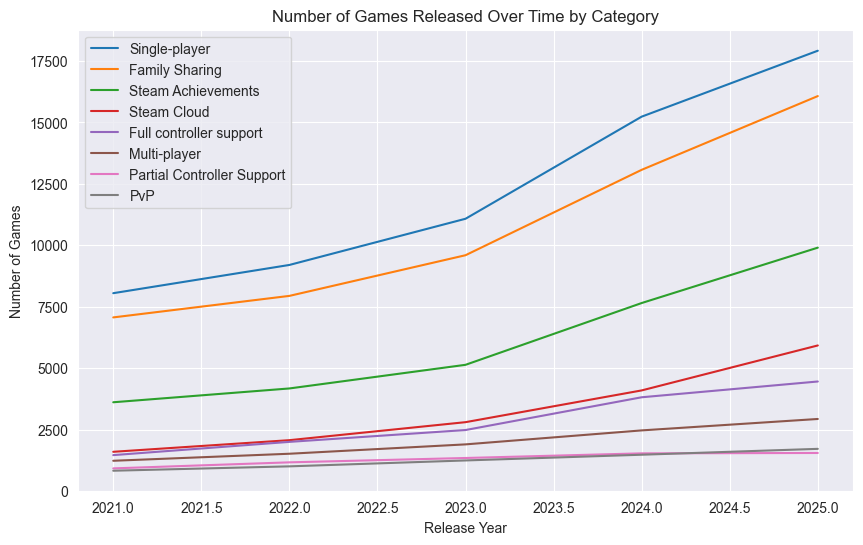

In [13]:
# Evolution of categories over time
plt.figure(figsize=(10, 6))
categories_sum = group_and_sum(
    data=data,
    groups=most_popular_categories.index[:-1],
    group_by="release_year",
    sum_by="categories",
)
multiple_lineplot(
    categories_sum,
    title="Number of Games Released Over Time by Category",
    xlabel="Release Year",
    ylabel="Number of Games",
)

In [14]:
# Test One-Hot Encoding to analyze the correlation
one_hot_encoding = data[["release_year", "release_date", "price", "recommendations"]]
one_hot_categories = data["categories"].str.get_dummies(";")
one_hot_genres = data["genres"].str.get_dummies(";")
one_hot_encoding = pd.concat(
    [one_hot_encoding, one_hot_genres, one_hot_categories], axis=1
)
correlations = one_hot_encoding.corr()
strong_corr = (
    correlations.where(np.triu(np.ones(correlations.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
strong_corr = strong_corr[abs(strong_corr) > 0.6]
popular = set(most_popular_genres.index[:-1]) | set(most_popular_categories.index[:-1])

for pair, value in strong_corr.items():
    matches = popular & set(pair)
    if matches:
        print(f"Tuple: {pair} | Correlation: {value:.2f} | Coincidence: {matches}")

Tuple: ('Free To Play', 'Family Sharing') | Correlation: -0.85 | Coincidence: {'Free To Play', 'Family Sharing'}
Tuple: ('Online PvP', 'PvP') | Correlation: 0.83 | Coincidence: {'PvP'}
Tuple: ('Multi-player', 'PvP') | Correlation: 0.76 | Coincidence: {'Multi-player', 'PvP'}
Tuple: ('Co-op', 'Multi-player') | Correlation: 0.74 | Coincidence: {'Multi-player'}
Tuple: ('Multi-player', 'Online PvP') | Correlation: 0.64 | Coincidence: {'Multi-player'}
Tuple: ('Multi-player', 'Online Co-op') | Correlation: 0.61 | Coincidence: {'Multi-player'}


In [15]:
# Price analysis
most_common_prices = data["price"].value_counts().head(10)
most_expensive_games = data.sort_values(by="price", ascending=False).head(10)[
    ["name", "price", "recommendations", "release_year"]
]
price_per_year_month = (
    data.groupby(["release_year", data["release_date"].dt.month])["price"]
    .median()
    .reset_index(name="price")
)
n_f2p_paid_games = (
    data["price"].apply(lambda x: "F2P" if x == 0 else "Paid").value_counts()
)
years_list = price_per_year_month["release_year"].unique()

print_analysis_results("Price statistics", calculate_stadistics(data["price"]))
print(
    f"================== Most expensive games ================== \n{most_expensive_games}\n"
)
print_analysis_results(
    "Paid and Free to Play game",
    {
        "Free to Play games": n_f2p_paid_games["F2P"],
        "Paid games": n_f2p_paid_games["Paid"],
    },
)

================== Price statistics ==================
count: 63995
mean: 7.0
mode: 0.0
median: 4.99
max: 1900.0
min: 0.0

================== Most expensive games ================== 
                                                   name    price  recommendations  release_year
61142                                     MolCollabo v2  1900.00                0          2025
34019                                 The Leverage Game   999.98                0          2023
32803                The Leverage Game Business Edition   999.98                0          2023
15749                                         Zekertune   615.38                0          2025
840                                           True Love   500.00                0          2024
37                                      Click and Relax   199.99                0          2021
2283   Maintenance Safety (Pipes and Acids) VR Training   199.99                0          2022
50581                     Hidden Industries Top-D

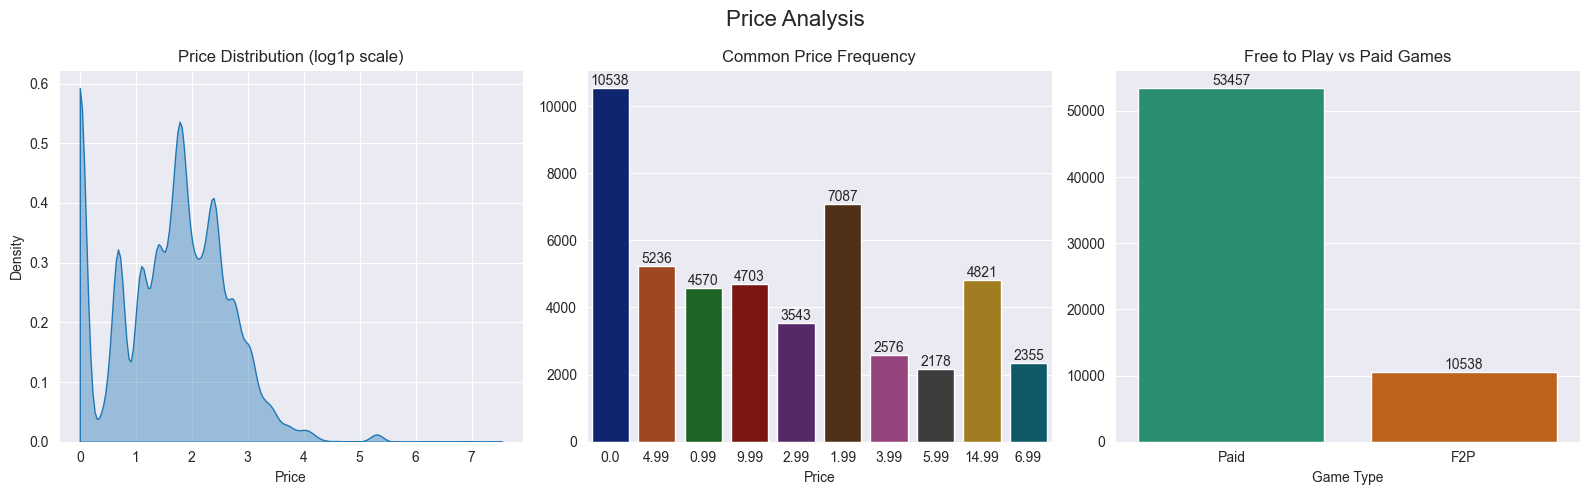

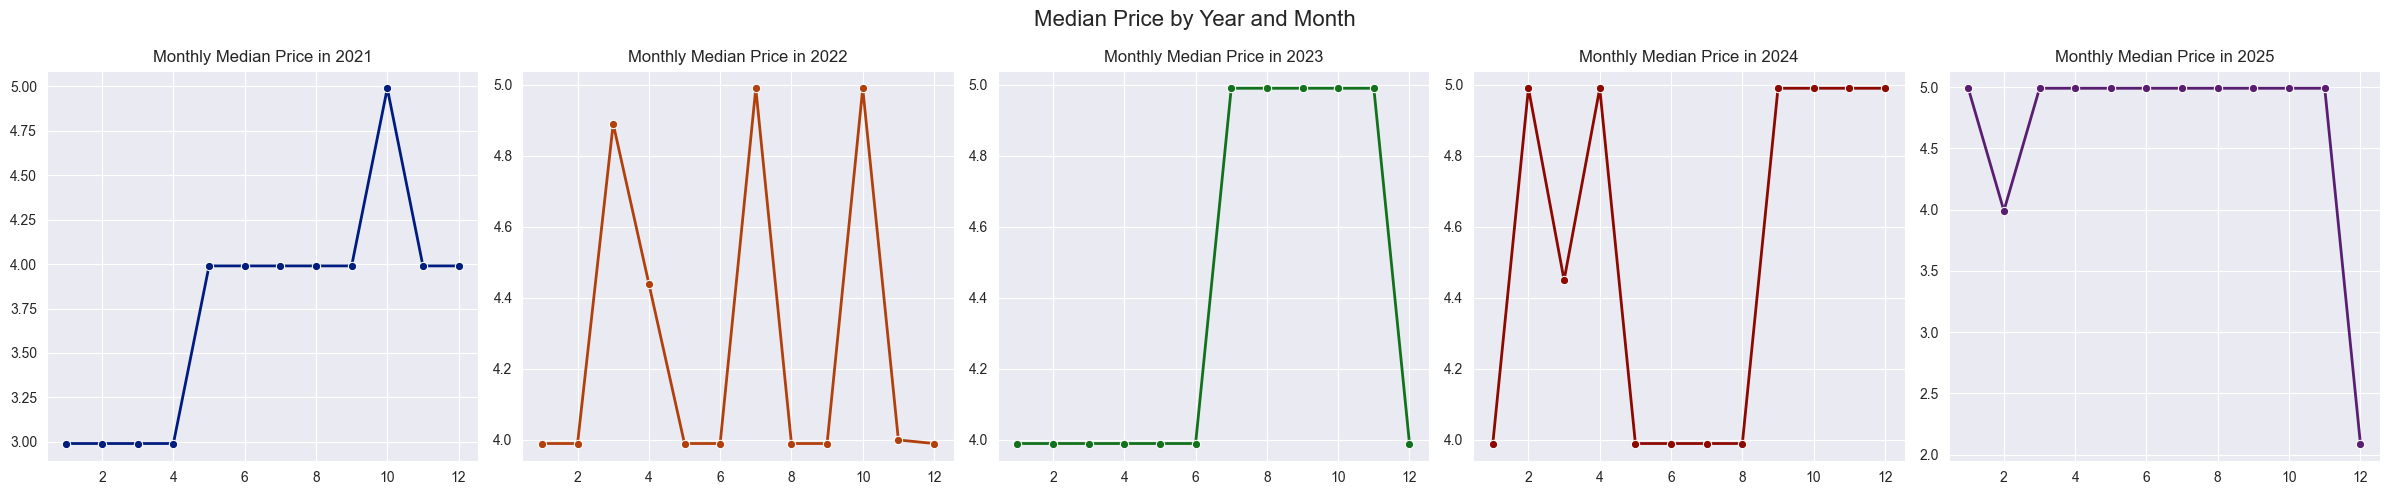

In [16]:
# Price analysis plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Price Analysis", fontsize=16)

make_plot(
    plot_type="kde",
    x_col=np.log1p(data["price"]),
    y_col=None,
    axes=axes[0],
    title="Price Distribution (log1p scale)",
    xlabel="Price",
    ylabel="Density",
)

make_plot(
    plot_type="bar",
    x_col=most_common_prices.index,
    y_col=most_common_prices.values,
    xticklabels=most_common_prices.index,
    axes=axes[1],
    title="Common Price Frequency",
    xlabel="Price",
    hue=most_common_prices.index,
    palette="dark",
)

make_plot(
    plot_type="bar",
    x_col=n_f2p_paid_games.index,
    y_col=n_f2p_paid_games.values,
    xticklabels=n_f2p_paid_games.index,
    axes=axes[2],
    hue=n_f2p_paid_games.index,
    palette="Dark2",
    title="Free to Play vs Paid Games",
    xlabel="Game Type",
)
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle("Median Price by Year and Month", fontsize=16)
price_palette = sns.color_palette("dark", n_colors=len(years_list))

for index, year in enumerate(years_list):
    montly_median_price = price_per_year_month[
        price_per_year_month["release_year"] == year
    ]
    make_plot(
        plot_type="line",
        data=montly_median_price,
        x_col="release_date",
        y_col="price",
        axes=axes[index],
        title=(f"Monthly Median Price in {year}"),
        color=price_palette[index],
    )
plt.show()

In [17]:
# Recommendations Analysys
recommendation_freq_of_freqs = freq_of_freqs(data["recommendations"])
most_recommended_games = data.sort_values(by="recommendations", ascending=False).head(
    10
)[["name", "recommendations", "release_year"]]
recommendations_stats = calculate_stadistics(data["recommendations"])
more_than_10_recommendations = data[data["recommendations"] > 10]
more_than_10_recommendations_months = pd.to_datetime(
    more_than_10_recommendations["release_date"]
).dt.month
print_analysis_results("Recommendations stats", recommendations_stats)
print_analysis_results(
    "Recommendations frequency",
    {
        "Games with 0 recommendations": (data["recommendations"] == 0).sum(),
        "Games between 1 and 9 recommendations": (
            (data["recommendations"] > 1) & (data["recommendations"] < 10)
        ).sum(),
        "Games with more than 10 recommendations": more_than_10_recommendations,
    },
)
print(
    f"================== Top 10 recommended games ================== \n{most_recommended_games}\n"
)

================== Recommendations stats ==================
count: 63995
mean: 370.0
mode: 0
median: 0.0
max: 862487
min: 0

================== Recommendations frequency ==================
Games with 0 recommendations: 56045
Games between 1 and 9 recommendations: 0
Games with more than 10 recommendations:          appid                                        name  release_year release_date                           genres                                                                                                                                                                                                                categories  price  recommendations             developer                           publisher
10     1543710                           Beyond Galaxyland          2024   2024-09-24       Action;Adventure;Indie;RPG                                                                                                                               Single-player;Steam Achieveme

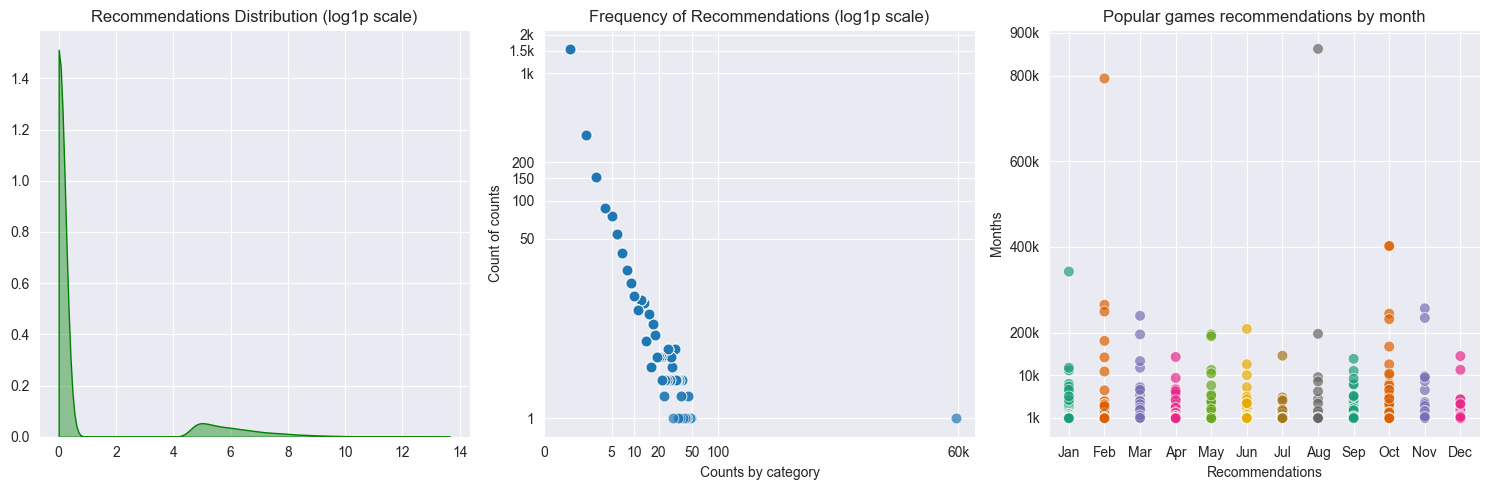

In [18]:
# Recommendations Analysys Plots
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
make_plot(
    plot_type="kde",
    x_col=np.log1p(data["recommendations"]),
    y_col=None,
    color="green",
    axes=ax[0],
    title="Recommendations Distribution (log1p scale)",
)
make_plot(
    plot_type="scatter",
    axes=ax[1],
    x_col=np.log1p(recommendation_freq_of_freqs["count"]),
    xlabel="Counts by category",
    ylabel="Count of counts",
    y_col=np.log1p(recommendation_freq_of_freqs["frequency"]),
    xticks=np.log1p([0, 5, 10, 20, 50, 100, 60000]),
    xticklabels=["0", "5", "10", "20", "50", "100", "60k"],
    yticks=np.log1p([1, 50, 100, 150, 200, 1000, 1500, 2000]),
    yticklabels=["1", "50", "100", "150", "200", "1k", "1.5k", "2k"],
    title="Frequency of Recommendations (log1p scale)",
)
make_plot(
    plot_type="scatter",
    axes=ax[2],
    x_col=more_than_10_recommendations_months,
    xlabel="Recommendations",
    ylabel="Months",
    y_col=more_than_10_recommendations["recommendations"],
    xticklabels=months_ticklabels,
    xticks=range(1, 13),
    yticklabels=["1k", "10k", "200k", "400k", "600k", "800k", "900k"],
    yticks=[1000, 100000, 200000, 400000, 600000, 800000, 900000],
    title="Popular games recommendations by month",
    hue=more_than_10_recommendations_months,
    palette="Dark2",
)
plt.show()

In [19]:
# developer and publisher analysis
developer_is_publisher = data["developer"] == data["publisher"]
developer_count = data["developer"].value_counts().head(10)
publisher_count = data["publisher"].value_counts().head(10)
print_analysis_results(
    "Developer and Publisher Analysis",
    {
        "Number of games where developer is publisher": developer_is_publisher.sum(),
        "Number of unique developers": data["developer"].unique().size,
        "Number of unique publishers": data["publisher"].unique().size,
    },
)

================== Developer and Publisher Analysis ==================
Number of games where developer is publisher: 46975
Number of unique developers: 44473
Number of unique publishers: 40205



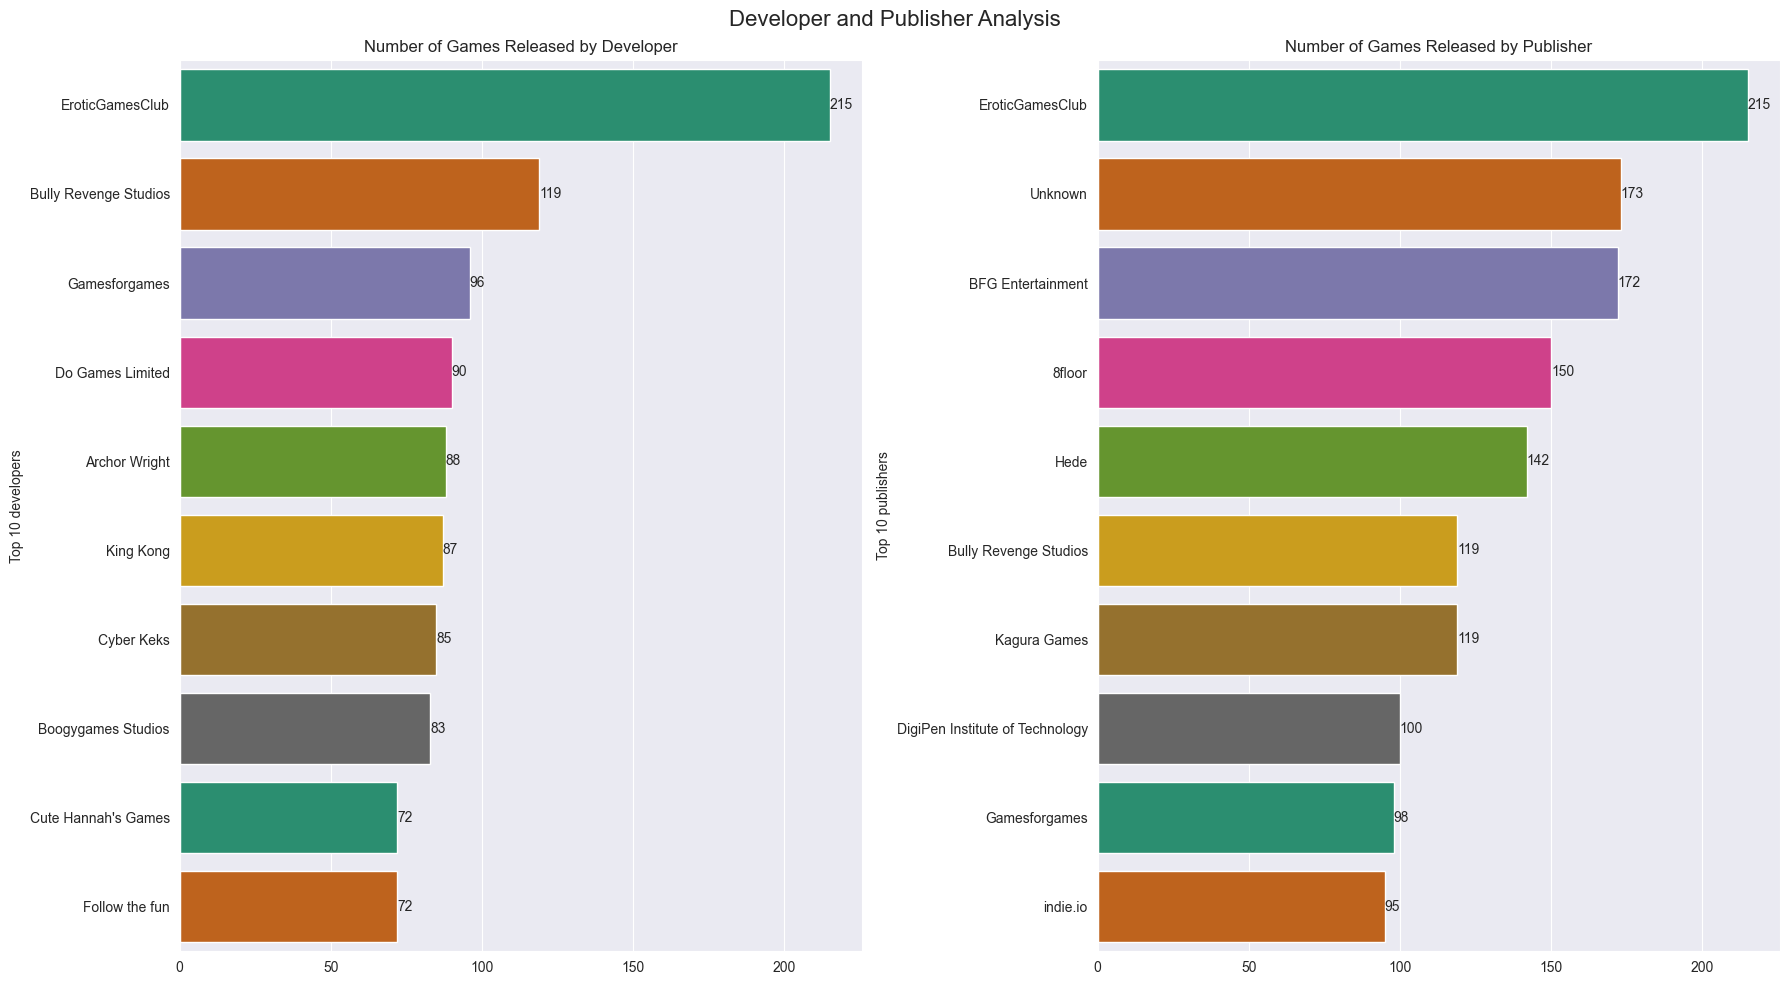

In [20]:
# developer and publisher analysis plots
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle("Developer and Publisher Analysis", fontsize=16)

make_plot(
    plot_type="bar",
    x_col=developer_count.values,
    y_col=developer_count.index,
    axes=axes[0],
    title="Number of Games Released by Developer",
    ylabel="Top 10 developers",
    yticklabels=developer_count.index,
    palette="Dark2",
    hue=developer_count.index,
)
make_plot(
    plot_type="bar",
    x_col=publisher_count.values,
    y_col=publisher_count.index,
    axes=axes[1],
    title="Number of Games Released by Publisher",
    ylabel="Top 10 publishers",
    yticklabels=publisher_count.index,
    palette="Dark2",
    hue=publisher_count.index,
)

## Multivariate Analysis

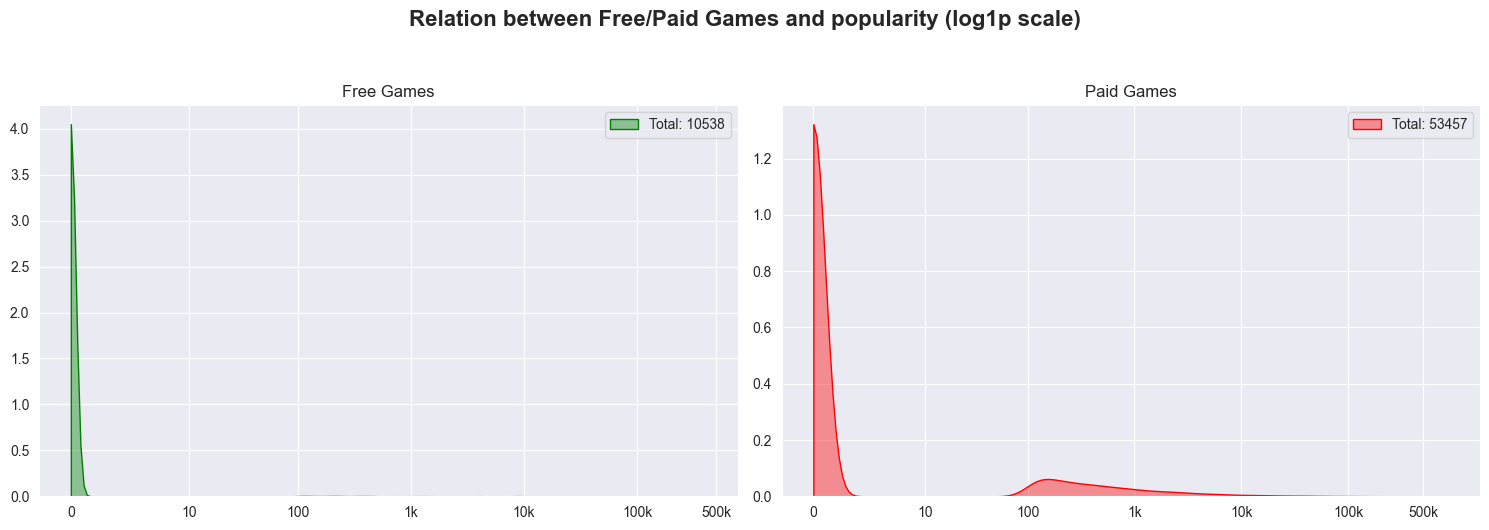

In [21]:
# Relation between Free/Paid Games popularity
f2p = data["price"] == 0
free_games = data[f2p]
paid_games = data[~f2p]
free_games_fof = freq_of_freqs(free_games)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Relation between Free/Paid Games and popularity (log1p scale)",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

make_plot(
    plot_type="kde",
    x_col=np.log1p(free_games["recommendations"]),
    y_col=None,
    axes=axes[0],
    title="Free Games",
    xticks=np.log1p([0, 10, 100, 1000, 10000, 100000, 500000]),
    xticklabels=["0", "10", "100", "1k", "10k", "100k", "500k"],
    legend=True,
    legend_label=f"Total: {len(free_games)}",
    color="green",
)
make_plot(
    plot_type="kde",
    x_col=np.log1p(paid_games["recommendations"]),
    y_col=None,
    axes=axes[1],
    title="Paid Games",
    xticks=np.log1p([0, 10, 100, 1000, 10000, 100000, 500000]),
    xticklabels=["0", "10", "100", "1k", "10k", "100k", "500k"],
    legend=True,
    legend_label=f"Total: {len(paid_games)}",
    color="red",
)

plt.show()

================== Free popular games statistics ==================
count: 85
mean: 13482.0
mode: 105
median: 401.0
max: 402294
min: 104

================== Paid popular games statistics ==================
count: 7865
mean: 2862.0
mode: 106
median: 349.0
max: 862487
min: 101



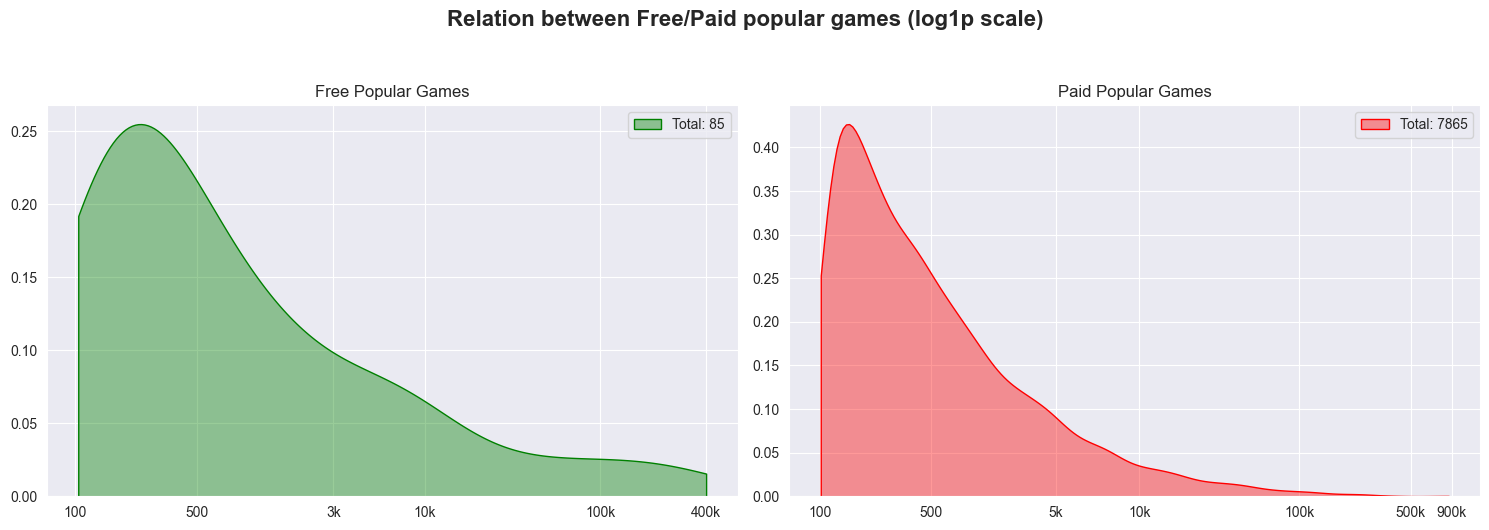

In [22]:
# Relation between Free/Paid most popular games
popular_games = data["recommendations"] > 0
free_popular_games = data[f2p & popular_games]["recommendations"]
paid_popular_games = data[~f2p & popular_games]["recommendations"]

free_popular_games_stats = calculate_stadistics(free_popular_games)
paid_popular_games_stats = calculate_stadistics(paid_popular_games)

print_analysis_results("Free popular games statistics", free_popular_games_stats)
print_analysis_results("Paid popular games statistics", paid_popular_games_stats)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Relation between Free/Paid popular games (log1p scale)",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

make_plot(
    plot_type="kde",
    x_col=np.log1p(free_popular_games),
    y_col=None,
    axes=axes[0],
    title="Free Popular Games",
    color="green",
    xticks=np.log1p([100, 500, 3000, 10000, 100000, 400000]),
    xticklabels=["100", "500", "3k", "10k", "100k", "400k"],
    legend=True,
    legend_label=f"Total: {len(free_popular_games)}",
)
make_plot(
    plot_type="kde",
    x_col=np.log1p(paid_popular_games),
    y_col=None,
    axes=axes[1],
    title="Paid Popular Games",
    color="red",
    xticks=np.log1p([100, 500, 3000, 10000, 100000, 500000, 900000]),
    xticklabels=["100", "500", "5k", "10k", "100k", "500k", "900k"],
    legend=True,
    legend_label=f"Total: {len(paid_popular_games)}",
)

plt.show()

In [23]:
# Insights during covid period
Pandemic = (data["release_date"] >= "2020-03-11") & (
    data["release_date"] <= "2023-05-05"
)
No_Pandemic_ = ~Pandemic
print(f'Average price during the pandemic: {data[Pandemic]["price"].mean()}')
print(f'Average price outside the pandemic: {data[No_Pandemic_]["price"].mean()}')
print(
    f'Average recommendations during the pandemic: {data[Pandemic]["recommendations"].mean()}'
)
print(
    f'Average recommendations outside the pandemic: {data[No_Pandemic_]["recommendations"].mean()}'
)

Average price during the pandemic: 6.936965662871833
Average price outside the pandemic: 7.582524934258841
Average recommendations during the pandemic: 432.45381931692987
Average recommendations outside the pandemic: 337.2640780839118


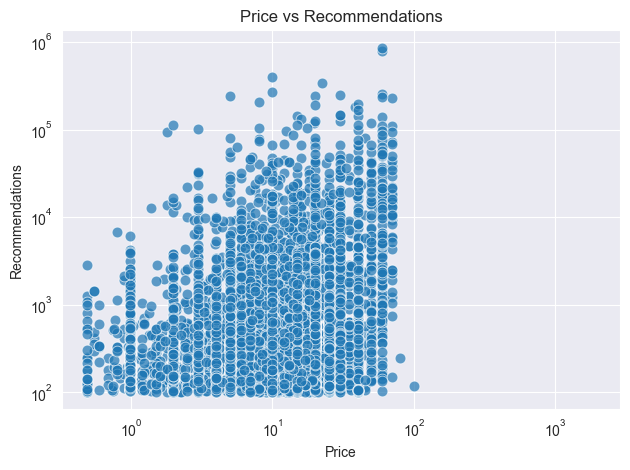

In [24]:
# Price vs Recommendations analysis
make_plot(
    plot_type="scatter",
    data=data,
    x_col="price",
    y_col="recommendations",
    axes=None,
    title="Price vs Recommendations",
    xlabel="Price",
    ylabel="Recommendations",
    xscale="log",
    yscale="log",
)

In [ ]:
eda_outputs = {
    "popular_genres": (
        most_popular_genres[most_popular_genres.values > genres_stats["median"]].index
    ).tolist(),
    "popular_categories": (
        most_popular_categories[
            most_popular_categories.values > categories_count_stats["median"]
        ].index
    ).tolist(),
    "redundant_correlation_features": ["PvP", "Co-op", 'Family Sharing'],
    "no_modelable_columns": [
        "name",
        "release_year",
        "release_date",
        "genres",
        "categories",
        "developer",
        "publisher",
    ],
}

export_eda_params(eda_outputs)